In [152]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
import pandas as pd
import seaborn as sns
from mpl_toolkits.axes_grid1 import host_subplot
from mpl_toolkits import axisartist
from rd_solver import *
sns.set(style='white')

import os

## Model description
Here is the extracelluar proofreading model through protein gradient. Inspired by [Rob Phillips (2020)](https://doi.org/10.7554/eLife.60415), we conceive that kinetic proofreading can also be achieved in extracelluar model and realize specific ligand transportation.  
To achieve this, the model we consider will be divided into modules:  
1, Gradient formation module: This module is responsible for the formation of substrate gradient.Here we use the classic source-sink model. [Stapornwongkul(2020)](https:/10.1126/science.abb8205) showed that if we can use simple ligand-receptor system can build synthetic gradient in tissue and here we use similar method to build substrate gradient.
2, Proofreading module: This module includes a carrier that can bind to substrate and prevent it from assosication with receptor. And because of the decreasing substrate gradient and the different unbinding rate of substrates and carrier, the ratio of different complexes will change as they diffuse. Under the right conditions, the concentration of substrate complexes with larger koff [EW] should be << the concentration of substrate complexes with smaller koff[ER],and the complex can form a complete protease to cleave the membrane bound GFP/mcherry:
$$
A+R \rightleftharpoons AR \rightharpoonup R +  A_{cut}\\
B+R \rightleftharpoons BR \rightharpoonup R +  B_{cut}\\
A+A' \rightleftharpoons AA'\\
B+A' \rightleftharpoons BA'\\
$$
The reaction-diffusion functions are as follows:
$$
\frac{\partial A}{\partial t} = D_1 \frac{\partial^2 A}{\partial x^2} - k_{AA'}[A][A'] + r_{
    AA'}[AA'] + r_{AR}[AR] - k_{AR}[A][R]\\ 
\frac{\partial B}{\partial t} = D_2 \frac{\partial^2 B}{\partial x^2} - k_{BA'}[B][A'] + r_{BA'}[BA'] + r_{BR}[BR] - k_{BR}[B][R]\\
\frac{\partial A'}{\partial t} = D_3 \frac{\partial^2 A'}{\partial x^2}
                                 - k_{AA'}[A][A'] + r_{AA'}[AA']
                                 - k_{BA'}[B][A'] + r_{BA'}[BA']\\
\frac{\partial R}{\partial t} = D_4 \frac{\partial^2 A}{\partial x^2} - k_{AR}[A][R] + r_{AR}[AR]
                                 - k_{BR}[B][R] + r_{BR}[BR]
                                 + \gamma([AR]+[BR])\\
\frac{\partial AR}{\partial t} = D_5 \frac{\partial^2 AR}{\partial x^2} - k_{AR}[A][R] - r_{AR}[AR] - \gamma[AR]\\
\frac{\partial BR}{\partial t} = D_6 \frac{\partial^2 BR}{\partial x^2} - k_{AR}[B][R] - r_{BR}[BR] - \gamma[BR]\\
\frac{\partial AA'}{\partial t} = D_7 \frac{\partial^2 AA'}{\partial x^2} + k_{AA'}[A][A'] - r_{AA'}[AA'] \\
\frac{\partial BA'}{\partial t} = D_8 \frac{\partial^2 BA'}{\partial x^2} + k_{BA'}[B][A'] - r_{BA'}[BA'] \\

\frac{\partial A_{cut}}{\partial t} = D_9 \frac{\partial^2 A_{cut}}{\partial x^2} + \gamma[AR]\\
\frac{\partial B_{cut}}{\partial t} = D_{10} \frac{\partial^2 B_{cut}}{\partial x^2} + \gamma[BR]\\
$$

In [153]:
class RXN_params_yuanqi(object):
    """
    Container for reaction parameters
    """
    def __init__(self, **kwargs):
        """
        k_AC: association rate for A and Receptor
        r_AC: dissociation rate for AA'
        k_AR: association rate for A and Receptor
        r_AR: dissociation rate for A-Receptor complex
        k_BC: association rate for B and Receptor
        r_BC: dissociation rate for BA'
        k_BR: association rate for B and Receptor
        r_BR: dissociation rate for B-Receptor complex
        RTotal: Total receptor number
        gamma: receptor turnover rate ([X-R] --> R)
        deg: universal degradation rate for free proteins
        """
        # RTotal: Total receptor number (nM) 
        #self.RTotal = 2.7 # nM  0.0375 – 2.7 nM (corresponding to 18 –1300 molecules/µm2 and a 800 µm Matrigel layer on the cell surface)
        # k (nM-1*s-1) and r (s-1) of A+A' <-> AA' 
        self.k_AC = 1e-4   # /nM/s
        self.r_AC = 1e-4  # /s
        # k (nM-1*s-1) and r (s-1) of B+A' <-> BA'
        self.k_BC = 1e-4 # nM/s
        self.r_BC = 1e-3  # /min
        # k (nM-1*s-1) and r (s-1) of A+Receptor <-> A-Receptor complex
        self.k_AR = 4.5e-4  # nM/s
        self.r_AR = 1e-3  # /min
        # k (nM-1*s-1) and r (s-1) of B+Receptor <-> B-Receptor complex
        self.k_BR = 4.5e-4  # nM/s
        self.r_BR = 1e-3  # /s
        # Recycling rate (s-1) of A-Receptor and B-Receptor
        self.gamma = 4e-4 
        
        self.ratio = self.r_BC/self.r_AC
        
        # Not considering basal degradation of species
        self.deg = 2e-5 

        # Hill function
        self.k = 1
        self.n = 1

        self.k_ac = 1
        self.n_ac = 1
        self.k_rp = 1
        self.n_rp = 1


        # Put in params that were specified in input
        for entry in kwargs:
            setattr(self, entry, kwargs[entry])

In [154]:
# Time points

t = np.arange(3600*1.0, 3600*48, 3600)

# number of grid points 
n_gridpoints = 451 # refer to the BMP model,because when their parameters are simulated, when L=3000, the value of citrine is close to 0
grid_spacing = 10 # µm refer to 293T cell length

# Physical length of system
L = grid_spacing * (n_gridpoints - 1) # µm

In [155]:
def get_fidelity(sol,params=RXN_params_yuanqi()):
    sol = np.array(sol)
    sol = np.array(sol)
    AC = sol[4,-1]
    BC = sol[5,-1]
    fidelity = AC/BC
    return fidelity

In [156]:
def get_increased_fidelity(sol, params=RXN_params_yuanqi()):
    sol = np.array(sol)
    AC = sol[4,-1]
    BC = sol[5,-1]
    fidelity = AC/BC
    increased_fidelity = fidelity/params.ratio
    return increased_fidelity

In [157]:
def get_AC(sol, params=RXN_params_yuanqi()):
    sol = np.array(sol)
    AC = sol[4,-1]
    return AC 

In [158]:
def get_BC(sol, params=RXN_params_yuanqi()):
    sol = np.array(sol)
    BC = sol[5,-1]
    return BC 

In [159]:
def if_proofreading(sol, params, BC_limit=0):
   increased_fidelity = get_increased_fidelity(sol,params)
   sol = np.array(sol)
   AC = sol[4,-1]
   for idx, value in enumerate(AC):
      #if value < BC_limit:
      if increased_fidelity[idx] > 50:
         return [idx+1, value]
      #else:
         #return False
   return False

In [160]:
rxn_params = RXN_params_yuanqi()
diff_coeffs = DIFFUSION()
n_gridpoints = 451
sender_region = 200
grid_spacing = 10 # µm
L = grid_spacing * (n_gridpoints - 1) # µm

rec_region = np.ones(n_gridpoints)
rec_region[:sender_region] = 0
# Initial concentration  
c_0_tuple = (np.zeros(n_gridpoints),np.zeros(n_gridpoints),
             np.zeros(n_gridpoints),np.zeros(n_gridpoints),
             np.zeros(n_gridpoints),np.zeros(n_gridpoints),
             np.zeros(n_gridpoints),np.zeros(n_gridpoints),np.zeros(n_gridpoints))
             

In [161]:
cases = [
    #[0, 0, 0, 0, 0],  # Case 0: no endocytosis receptor
    [1, 0, 0, 0, 0],  # Case 1: endocytosis receptor with no feedback
    [1, 0, 1, 0, 0],  # Case 3: AAp -- AAp
    [1, 0, 0, 0, 1]   # Case 7: rp_ac
]
labels = ('without feedback', 
          'with SA', 'with SAMI')

In [162]:
j_basal = 3e-3

In [163]:
numbers = [0,2]


Processing case 0: without feedback

Processing case 2: with SAMI


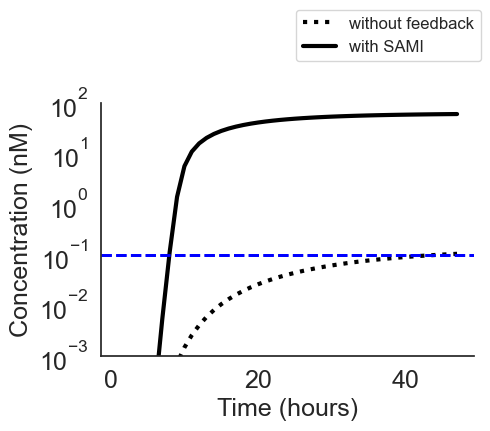

In [164]:

if not os.path.exists('figures_S6'):
    os.makedirs('figures_S6')

linestyles = ['dotted','--',   '-']
# Define colors, markers, cases, and labels
colors = ['#006d2c', '#E9C46A', '#00A0E9', '#00A0E9']
colors_BR= ['#1f77b4', '#d62728', '#ff7f0e', '#2ca02c'] 
markers = ['p', 's', 'd', '*', 'v', '<', '>']

x = np.linspace(0, L, n_gridpoints)

# Process each case
    # Initialize figure for plotting time vs sol[4]
fig_speed1, ax = plt.subplots(figsize=(5, 5))
for i in numbers:
    print(f"\nProcessing case {i}: {labels[i]}")
    rxn_params = RXN_params_yuanqi()
    
    # Process parameter sets until fidelity > 1e4 and activity > 1e-1
    j_A = np.zeros(n_gridpoints)
    j_A[0:sender_region] = j_basal
    j_B = np.zeros(n_gridpoints)
    j_B[0:sender_region] = j_basal
    j_C = np.zeros(n_gridpoints)
    j_C[0:sender_region] = j_basal*2

    # Initialize parameters with cases scaling
    j_R = np.zeros(n_gridpoints)
    j_R[sender_region:] = 4e-4 * cases[i][0]
    j_self_activation_ar_on_a = j_self_activation_br_on_b = np.zeros(n_gridpoints)
    j_self_activation_ar_on_a[sender_region:] = j_self_activation_br_on_b[sender_region:] = j_basal * cases[i][1]
    j_self_activation_ac_on_ac = j_self_activation_bc_on_bc = np.zeros(n_gridpoints)
    j_self_activation_ac_on_ac[sender_region:] = j_self_activation_bc_on_bc[sender_region:] = j_basal* cases[i][2]
    j_mutual_inhibition_ac_on_bc = j_mutual_inhibition_bc_on_ac = np.zeros(n_gridpoints)
    j_mutual_inhibition_ac_on_bc[sender_region:] = j_mutual_inhibition_bc_on_ac[sender_region:] =j_basal* cases[i][3]
    j_ac_rp = np.zeros(n_gridpoints)
    j_ac_rp[sender_region:] =j_basal * cases[i][4]
    
    
    production_rate = (
        j_A, j_B, j_C,
        j_self_activation_ar_on_a, j_self_activation_br_on_b,
        j_self_activation_ac_on_ac, j_self_activation_bc_on_bc,
        j_mutual_inhibition_ac_on_bc, j_mutual_inhibition_bc_on_ac,
        j_ac_rp, j_R
    )
    
    sol = RD_solve(
        c_0_tuple, t, L=L, derivs_0=0, derivs_L=0,
        diff_coeff_fun=Diff_fun, diff_coeff_params=(diff_coeffs,),
        rxn_fun=RD_rxn, rxn_params=(rxn_params, production_rate),
        rtol=1.49012e-8, atol=1.49012e-8
    )

    fidelity_end = np.where(sol[5][-1,-1]!= 0, sol[4][-1,-1] / sol[5][-1,-1], np.inf)
    fidelity = sol[4][-1]/sol[5][-1]
    

    # Define time array, ensuring it has the same length as sol[4]
    time_max = 48  # Max time (48 hours)
    time_gridpoint = 3600  # 1 hour time step
    t_space = np.arange(3600 * 1.0, 3600 * time_max, time_gridpoint)

    # Ensure that `sol[4]` has the same length as `t_space`
    # Assuming sol[4] has the shape (101, n_gridpoints), we'll slice it to match `t_space`
    if len(t_space) > sol[4].shape[0]:
        raise ValueError("Time grid `t_space` exceeds the number of time steps in `sol[4]`.")

    # Slice `sol[4]` to match the time points in `t_space`
    ER_slice = sol[4][:len(t_space), -1]  # Get only the relevant portion of sol[4]
    EW_slice = sol[5][:len(t_space), -1]  # Get only the relevant portion of sol[4]

    # Plot sol[4] (ER concentration) vs time EW(t)
    ax.semilogy(t_space / 3600, ER_slice, color='black', alpha=1, linewidth=3, linestyle=linestyles[i],label=labels[i])
    #ax.semilogy(t_space / 3600, EW_slice, linewidth=4, color='#CD5C4A', label='EW')

    # Add horizontal line at y = 1e-1 on the left y-axis (ER concentration)
    ax.axhline(1e-1, color='blue', linestyle='--', linewidth=2)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlabel("Time (hours)", fontsize=18)
    ax.set_ylabel("Concentration (nM)", fontsize=18)
    #ax.legend(loc='upper right', bbox_to_anchor=(0.5, 1.40), fontsize=12)
    ax.tick_params(labelsize=18)
    ax.set_ylim(ymin=1e-3, ymax=1e2)
    '''
    # Create second y-axis for fidelity plot
    ax2 = ax.twinx()

    ax2.semilogy(t_space / 3600, ER_slice/EW_slice, linewidth=3, label='Fidelity'+labels[i], color='k')

    # Add horizontal line at y = 1e4 on the right y-axis (EW concentration)
    ax2.axhline(1e4, color='gray', linestyle='--', linewidth=2, label='fidelity = 1e4 ')

    ax2.spines["top"].set_visible(False)
    ax2.set_ylabel("Fidelity", fontsize=18)
    #ax2.legend(loc='upper left', bbox_to_anchor=(0.5, 1.40), fontsize=12)
    ax2.tick_params(labelsize=18)
    '''
plt.legend(loc='upper left', bbox_to_anchor=(0.5, 1.40), fontsize=12)
# Adjust layout to prevent overlap
fig_speed1.tight_layout()
fig_speed1.savefig(f'overthreshold_activity.svg')
    # Display the plot
plt.show(fig_speed1)
plt.close(fig_speed1)


Processing case 0: without feedback


/var/folders/fd/b1g1fr5n7xv98s13rfl1ncyw0000gn/T/ipykernel_97315/3528978287.py:76: RuntimeWarning: invalid value encountered in divide
  ax2.semilogy(t_space / 3600, ER_slice/EW_slice, linewidth=3,color='black', alpha=1,linestyle=linestyles[i], label=labels[i])



Processing case 2: with SAMI


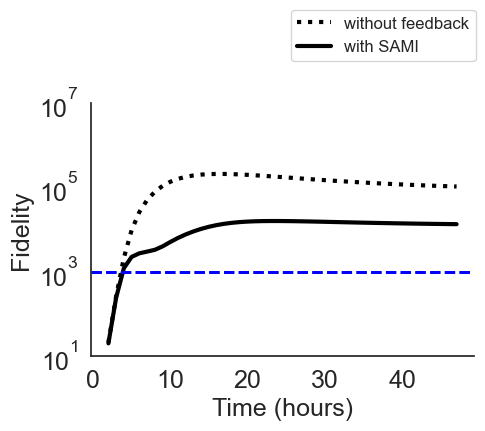

In [165]:

linestyles = ['dotted','--',   '-']

fig_speed2, ax2 = plt.subplots(figsize=(5, 5))
for i in numbers:
    print(f"\nProcessing case {i}: {labels[i]}")
    rxn_params = RXN_params_yuanqi()
    
    # Process parameter sets until fidelity > 1e4 and activity > 1e-1
    j_A = np.zeros(n_gridpoints)
    j_A[0:sender_region] = j_basal
    j_B = np.zeros(n_gridpoints)
    j_B[0:sender_region] = j_basal
    j_C = np.zeros(n_gridpoints)
    j_C[0:sender_region] = j_basal*2

    # Initialize parameters with cases scaling
    j_R = np.zeros(n_gridpoints)
    j_R[sender_region:] = 4e-4 * cases[i][0]
    j_self_activation_ar_on_a = j_self_activation_br_on_b = np.zeros(n_gridpoints)
    j_self_activation_ar_on_a[sender_region:] = j_self_activation_br_on_b[sender_region:] = j_basal * cases[i][1]
    j_self_activation_ac_on_ac = j_self_activation_bc_on_bc = np.zeros(n_gridpoints)
    j_self_activation_ac_on_ac[sender_region:] = j_self_activation_bc_on_bc[sender_region:] = j_basal* cases[i][2]
    j_mutual_inhibition_ac_on_bc = j_mutual_inhibition_bc_on_ac = np.zeros(n_gridpoints)
    j_mutual_inhibition_ac_on_bc[sender_region:] = j_mutual_inhibition_bc_on_ac[sender_region:] =j_basal* cases[i][3]
    j_ac_rp = np.zeros(n_gridpoints)
    j_ac_rp[sender_region:] =j_basal * cases[i][4]
    
    production_rate = (
        j_A, j_B, j_C,
        j_self_activation_ar_on_a, j_self_activation_br_on_b,
        j_self_activation_ac_on_ac, j_self_activation_bc_on_bc,
        j_mutual_inhibition_ac_on_bc, j_mutual_inhibition_bc_on_ac,
        j_ac_rp, j_R
    )
    
    sol = RD_solve(
        c_0_tuple, t, L=L, derivs_0=0, derivs_L=0,
        diff_coeff_fun=Diff_fun, diff_coeff_params=(diff_coeffs,),
        rxn_fun=RD_rxn, rxn_params=(rxn_params, production_rate),
        rtol=1.49012e-8, atol=1.49012e-8
    )

    fidelity_end = np.where(sol[5][-1,-1]!= 0, sol[4][-1,-1] / sol[5][-1,-1], np.inf)
    fidelity = sol[4][-1]/sol[5][-1]
    

    # Define time array, ensuring it has the same length as sol[4]
    time_max = 48  # Max time (48 hours)
    time_gridpoint = 3600  # 1 hour time step
    t_space = np.arange(3600 * 1.0, 3600 * time_max, time_gridpoint)

    # Ensure that `sol[4]` has the same length as `t_space`
    # Assuming sol[4] has the shape (101, n_gridpoints), we'll slice it to match `t_space`
    if len(t_space) > sol[4].shape[0]:
        raise ValueError("Time grid `t_space` exceeds the number of time steps in `sol[4]`.")

    # Slice `sol[4]` to match the time points in `t_space`
    ER_slice = sol[4][:len(t_space), -1]  # Get only the relevant portion of sol[4]
    EW_slice = sol[5][:len(t_space), -1]  # Get only the relevant portion of sol[4]

    '''
    # Plot sol[4] (ER concentration) vs time EW(t)
    ax.semilogy(t_space / 3600, ER_slice, linewidth=4, color=colors_BR[i],label=labels[i])
    #ax.semilogy(t_space / 3600, EW_slice, linewidth=4, color='#CD5C4A', label='EW')

    # Add horizontal line at y = 1e-1 on the left y-axis (ER concentration)
    ax.axhline(1e-1, color='blue', linestyle='--', linewidth=2)

    ax.spines["top"].set_visible(False)
    ax.set_xlabel("Time (hours)", fontsize=18)
    ax.set_ylabel("Concentration (nM)", fontsize=18)
    #ax.legend(loc='upper right', bbox_to_anchor=(0.5, 1.40), fontsize=12)
    ax.tick_params(labelsize=18)
    ax.set_ylim(ymin=1e-3, ymax=1e0)
    '''
    ax2.semilogy(t_space / 3600, ER_slice/EW_slice, linewidth=3,color='black', alpha=1,linestyle=linestyles[i], label=labels[i])

    ax2.axhline(1e3, color='blue', linestyle='--', linewidth=2)

    ax2.spines["top"].set_visible(False)
    ax2.spines["right"].set_visible(False) 
    ax2.set_ylabel("Fidelity", fontsize=18)
    ax2.set_xlabel("Time (hours)", fontsize=18)
    #ax2.legend(loc='upper left', bbox_to_anchor=(0.5, 1.40), fontsize=12)
    ax2.tick_params(labelsize=18)

    ax2.set_ylim(ymin=1e1, ymax=1e7)

plt.legend(loc='upper left', bbox_to_anchor=(0.5, 1.40), fontsize=12)
# Adjust layout to prevent overlap
fig_speed2.tight_layout()
fig_speed2.savefig(f'overthreshold_fidelity.svg')
    # Display the plot
plt.show(fig_speed2)
plt.close(fig_speed2)


Processing case 0: without feedback
[1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2
 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2
 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2
 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2
 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2
 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2
 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2
 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2
 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2
 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2
 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2
 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2
 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2 1987.2
 1987.2 1987.2 1987.2 1987.2 1987.2 1987

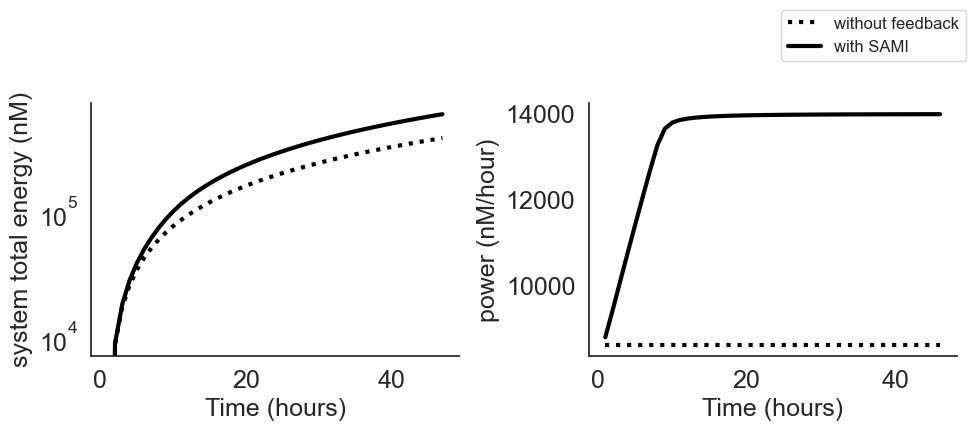

In [166]:

linestyles = ['dotted','--',   '-']
cases = [
    #[0, 0, 0, 0, 0],  # Case 0: no endocytosis receptor
    [1, 0, 0, 0, 0],  # Case 1: endocytosis receptor with no feedback
    [1, 0, 1, 0, 0],  # Case 3: AAp -- AAp
    [1, 0, 0, 0, 1]   # Case 7: rp_ac
]
labels = ('without feedback', 
          'with SA', 'with SAMI')

fig, ax= plt.subplots(1, 2, figsize=(10, 5))

for i in numbers:
    print(f"\nProcessing case {i}: {labels[i]}")
    rxn_params = RXN_params_yuanqi()
    
    # Process parameter sets until fidelity > 1e4 and activity > 1e-1
    j_A = np.zeros(n_gridpoints)
    j_A[0:sender_region] = j_basal
    j_B = np.zeros(n_gridpoints)
    j_B[0:sender_region] = j_basal
    j_C = np.zeros(n_gridpoints)
    j_C[0:sender_region] = j_basal*2

    # Initialize parameters with cases scaling
    j_R = np.zeros(n_gridpoints)
    j_R[sender_region:] = 4e-4 * cases[i][0]
    j_self_activation_ar_on_a = j_self_activation_br_on_b = np.zeros(n_gridpoints)
    j_self_activation_ar_on_a[sender_region:] = j_self_activation_br_on_b[sender_region:] = j_basal * cases[i][1]
    j_self_activation_ac_on_ac = j_self_activation_bc_on_bc = np.zeros(n_gridpoints)
    j_self_activation_ac_on_ac[sender_region:] = j_self_activation_bc_on_bc[sender_region:] = j_basal * cases[i][2]
    j_mutual_inhibition_ac_on_bc = j_mutual_inhibition_bc_on_ac = np.zeros(n_gridpoints)
    j_mutual_inhibition_ac_on_bc[sender_region:] = j_mutual_inhibition_bc_on_ac[sender_region:] =j_basal * cases[i][3]
    j_ac_rp = np.zeros(n_gridpoints)
    j_ac_rp[sender_region:] =j_basal * cases[i][4]
    
    
    production_rate = (
        j_A, j_B, j_C,
        j_self_activation_ar_on_a, j_self_activation_br_on_b,
        j_self_activation_ac_on_ac, j_self_activation_bc_on_bc,
        j_mutual_inhibition_ac_on_bc, j_mutual_inhibition_bc_on_ac,
        j_ac_rp, j_R
    )
    
    sol = RD_solve(
        c_0_tuple, t, L=L, derivs_0=0, derivs_L=0,
        diff_coeff_fun=Diff_fun, diff_coeff_params=(diff_coeffs,),
        rxn_fun=RD_rxn, rxn_params=(rxn_params, production_rate),
        rtol=1.49012e-8, atol=1.49012e-8
    )

    fidelity = sol[4][-1]/sol[5][-1]

    #print(sol[9])
    print(sol[8][-1])
    print(f"Shape of sol[8]: {sol[8].shape}")
    print(f"Length of t_space: {len(t_space)}")


    # Ensure energy has a value for each time step
    energy = np.array([np.sum(sol[8][t_idx, :]) for t_idx in range(len(t_space))])


     # Get only the relevant portion of sol[4]
    #EW_slice = sol[5][:len(t_space), -1]  # Get only the relevant portion of sol[4]

    # Plot sol[4] (ER concentration) vs time EW(t)
    ax[0].semilogy(t_space / 3600, energy, color='black', alpha=1, linewidth=3, linestyle=linestyles[i],label=labels[i])

    ax[0].spines["top"].set_visible(False)
    ax[0].spines["right"].set_visible(False) 
    ax[0].set_ylabel("system total energy (nM)", fontsize=18)
    ax[0].set_xlabel("Time (hours)", fontsize=18)
    #ax2.legend(loc='upper left', bbox_to_anchor=(0.5, 1.40), fontsize=12)
    ax[0].tick_params(labelsize=18)

    #ax2.set_ylim(ymin=1e1, ymax=1e7)

    power = energy[1:] - energy[:-1] # unit: nM / hour
    ax[1].plot(t_space[:-1] / 3600, power, color='black', alpha=1, linewidth=3, linestyle=linestyles[i],label=labels[i])
    ax[1].spines["top"].set_visible(False)
    ax[1].spines["right"].set_visible(False) 
    ax[1].set_ylabel("power (nM/hour)", fontsize=18)
    ax[1].set_xlabel("Time (hours)", fontsize=18)
    ax[1].tick_params(labelsize=18)
    #ax[1].set_ylim([0,1550])


    
plt.legend(loc='upper left', bbox_to_anchor=(0.5, 1.40), fontsize=12)
# Adjust layout to prevent overlap
fig.tight_layout()
fig.savefig(f'energy.svg')
    # Display the plot
plt.show(fig)
plt.close(fig)